In [7]:
import mitsuba as mi
import drjit as dr
mi.set_variant('cuda_ad_mono_polarized', 'llvm_ad_mono_polarized')

import sionna.rt
from sionna.rt import load_scene, PlanarArray, Transmitter, RadioMapSolver
import numpy as np
import matplotlib.pyplot as plt

## 1. Building geometry 추출 (BS 배치용)

In [8]:
# unmerged로 개별 건물 추출
scene_raw = load_scene(sionna.rt.scene.munich, merge_shapes=False)

buildings = []
for name, obj in scene_raw.objects.items():
    bbox = obj.mi_mesh.bbox()
    mn = [float(bbox.min[0]), float(bbox.min[1]), float(bbox.min[2])]
    mx = [float(bbox.max[0]), float(bbox.max[1]), float(bbox.max[2])]
    h = mx[2] - mn[2]
    fx, fy = mx[0]-mn[0], mx[1]-mn[1]
    if h > 3.0 and fx < 500 and fy < 500:
        buildings.append(dict(name=name, mn=mn, mx=mx,
            cx=(mn[0]+mx[0])/2, cy=(mn[1]+mx[1])/2,
            roof=mx[2], h=h, fx=fx, fy=fy))

print(f'{len(buildings)} buildings, median roof={np.median([b["roof"] for b in buildings]):.1f}m')
del scene_raw

1288 buildings, median roof=16.7m


## 2. 3GPP UMi BS 배치 함수

In [9]:
def place_bs_umi(buildings, num_bs, target_isd=200, bs_height=10.0,
                 core_hx=400, core_hy=300):
    """Hex grid -> snap to building rooftop -> farthest-point sampling."""
    cx = np.mean([b['cx'] for b in buildings])
    cy = np.mean([b['cy'] for b in buildings])
    dx, dy = target_isd, target_isd * np.sqrt(3) / 2

    # hex grid candidates
    cands = []
    for row in range(int(2*core_hy/dy) + 2):
        for col in range(int(2*core_hx/dx) + 2):
            x = (cx - core_hx) + col*dx + (row%2)*dx/2
            y = (cy - core_hy) + row*dy
            if cx-core_hx <= x <= cx+core_hx and cy-core_hy <= y <= cy+core_hy:
                cands.append([x, y])

    # snap to nearest building rooftop
    placed = []
    for xc, yc in cands:
        best, best_s = None, -np.inf
        for b in buildings:
            d = np.hypot(b['cx']-xc, b['cy']-yc)
            if d > 80 or b['roof'] < 5 or b['roof'] > 25:
                continue
            dx_ = (xc - b['cx']) / (d + 1e-6)
            dy_ = (yc - b['cy']) / (d + 1e-6)
            ex = b['mx'][0] if dx_ > 0 else b['mn'][0]
            ey = b['mx'][1] if dy_ > 0 else b['mn'][1]
            pos = [ex + dx_*1.0, ey + dy_*1.0, max(b['roof'], bs_height)]
            s = -np.hypot(pos[0]-xc, pos[1]-yc)*0.5 - abs(b['roof']-12)*2
            if s > best_s:
                best, best_s = pos, s
        if best is None:
            best = [xc, yc, bs_height]
        placed.append(best)

    # farthest-point sampling
    pts = np.array(placed)
    sel = [int(np.argmin(np.hypot(pts[:,0]-cx, pts[:,1]-cy)))]
    for _ in range(min(num_bs-1, len(placed)-1)):
        md = np.full(len(placed), np.inf)
        for s in sel:
            md = np.minimum(md, np.hypot(pts[:,0]-pts[s,0], pts[:,1]-pts[s,1]))
        for s in sel: md[s] = -1
        sel.append(int(np.argmax(md)))

    result = [placed[i] for i in sel]
    nn = []
    for i in range(len(result)):
        ds = [np.hypot(result[i][0]-result[j][0], result[i][1]-result[j][1])
              for j in range(len(result)) if i!=j]
        nn.append(min(ds))
    print(f'  {num_bs} BS: NN-ISD min={min(nn):.0f}m max={max(nn):.0f}m mean={np.mean(nn):.0f}m')
    return result

## 3. BS 배치 계산 (8 / 12 / 16개)

In [10]:
configs = [
    (8,  200, '8 BS (ISD~200m)'),
    (12, 160, '12 BS (ISD~160m)'),
    (16, 130, '16 BS (ISD~130m)'),
]
all_pos = {}
for n, isd, label in configs:
    all_pos[label] = place_bs_umi(buildings, n, target_isd=isd)

  8 BS: NN-ISD min=202m max=351m mean=260m
  12 BS: NN-ISD min=166m max=298m mean=227m
  16 BS: NN-ISD min=139m max=264m mean=171m


## 4. BS 배치 + 건물 footprint 시각화 (radio map 없이)

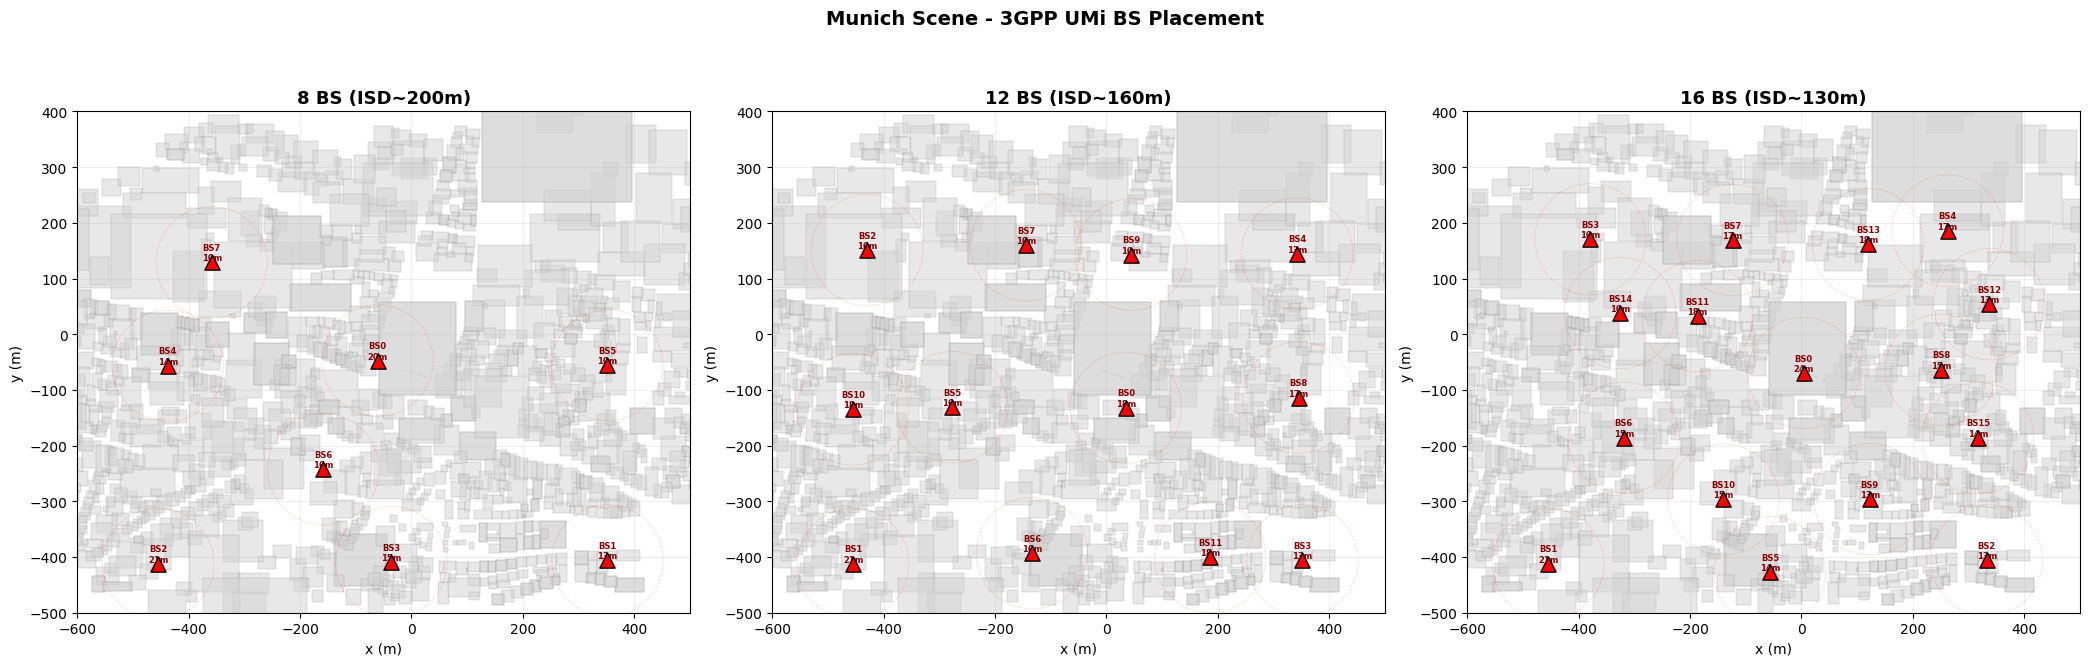

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, (label, bs_pos) in zip(axes, all_pos.items()):
    for b in buildings:
        ax.add_patch(plt.Rectangle(
            (b['mn'][0], b['mn'][1]), b['fx'], b['fy'],
            lw=0.3, ec='gray', fc='lightgray', alpha=0.5))
    bs = np.array(bs_pos)
    ax.scatter(bs[:,0], bs[:,1], c='red', marker='^', s=120,
               edgecolors='black', linewidths=1, zorder=10)
    for i, p in enumerate(bs_pos):
        ax.annotate(f'BS{i}\n{p[2]:.0f}m', (p[0],p[1]), fontsize=6,
                   ha='center', va='bottom', color='darkred', fontweight='bold')
        ax.add_patch(plt.Circle((p[0],p[1]), 100, fill=False,
                    ls='--', color='red', alpha=0.2, lw=0.5))
    ax.set_xlim(-600, 500); ax.set_ylim(-500, 400)
    ax.set_aspect('equal'); ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.grid(True, alpha=0.2)
fig.suptitle('Munich Scene - 3GPP UMi BS Placement', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Radio Map 커버리지 비교 (RSS + SINR)

In [ ]:
from sionna.rt.utils import watt_to_dbm

def make_scene(bs_positions, freq=28e9):
    scene = load_scene(sionna.rt.scene.munich, merge_shapes=True)
    scene.frequency = freq
    scene.bandwidth = 400e6
    scene.temperature = 293.0
    scene.tx_array = PlanarArray(num_rows=2, num_cols=2,
        vertical_spacing=0.5, horizontal_spacing=0.5,
        pattern='iso', polarization='V')
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1,
        vertical_spacing=0.5, horizontal_spacing=0.5,
        pattern='dipole', polarization='cross')
    for i, pos in enumerate(bs_positions):
        scene.add(Transmitter(name=f'bs_{i}',
                  position=[float(pos[0]), float(pos[1]), float(pos[2])],
                  power_dbm=40.0, orientation=[0,0,0], display_radius=10))
    return scene

fig, axes = plt.subplots(2, 3, figsize=(21, 14))
solver = RadioMapSolver()

for col, (label, bs_pos) in enumerate(all_pos.items()):
    print(f'Computing {label}...')
    sc = make_scene(bs_pos)
    rm = solver(scene=sc, cell_size=(2.0, 2.0), samples_per_tx=10_000_000,
               max_depth=5, los=True, specular_reflection=True,
               diffuse_reflection=True, refraction=True,
               diffraction=True, edge_diffraction=True)

    tx_idx = rm.tx_cell_indices

    # RSS
    rss = watt_to_dbm(rm.transmitter_radio_map('rss')).numpy()
    im0 = axes[0, col].imshow(rss, origin='lower')
    axes[0, col].set_title(f'{label}\nRSS (dBm)', fontsize=11)
    plt.colorbar(im0, ax=axes[0, col], label='RSS [dBm]')
    for i in range(len(bs_pos)):
        axes[0, col].scatter(tx_idx.x[i], tx_idx.y[i], c='red', marker='^',
            s=80, edgecolors='black', linewidths=0.5, zorder=10)

    # SINR
    sinr = (10. * np.log10(rm.transmitter_radio_map('sinr').numpy() + 1e-30))
    im1 = axes[1, col].imshow(sinr, origin='lower')
    axes[1, col].set_title(f'{label}\nSINR (dB)', fontsize=11)
    plt.colorbar(im1, ax=axes[1, col], label='SINR [dB]')
    for i in range(len(bs_pos)):
        axes[1, col].scatter(tx_idx.x[i], tx_idx.y[i], c='red', marker='^',
            s=80, edgecolors='black', linewidths=0.5, zorder=10)

    dr.flush_malloc_cache(); dr.flush_kernel_cache()
    del sc
    print(f'  Done: {label}')

fig.suptitle('Munich Scene @ 28 GHz - Coverage Comparison (3GPP UMi)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. 기존 BS 배치 (현재 config) vs 새 배치 비교

In [ ]:
# 기존 config.py의 BS 배치
old_bs = [
    [-14.111, -164.816, 89.889],
    [-22.006, -57.554, 79.995],
    [144.688, -216.653, 53.074],
    [216.867, 352.080, 40.000],
    [-356.179, 177.271, 27.432],
    [-538.142, -184.078, 18.713],
    [-407.187, -144.209, 18.778],
    [-324.530, 288.101, 16.572],
]

new_bs = all_pos['8 BS (ISD~200m)']

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for col, (label, bs_pos) in enumerate([('OLD (rooftop, 16~90m)', old_bs),
                                        ('NEW 3GPP UMi (10~20m)', new_bs)]):
    print(f'Computing {label}...')
    sc = make_scene(bs_pos)
    rm = solver(scene=sc, cell_size=(2.0, 2.0), samples_per_tx=10_000_000,
               max_depth=5, los=True, specular_reflection=True,
               diffuse_reflection=True, refraction=True,
               diffraction=True, edge_diffraction=True)

    tx_idx = rm.tx_cell_indices

    # RSS
    rss = watt_to_dbm(rm.transmitter_radio_map('rss')).numpy()
    im0 = axes[0, col].imshow(rss, origin='lower')
    axes[0, col].set_title(f'{label}\nRSS (dBm)', fontsize=11)
    plt.colorbar(im0, ax=axes[0, col], label='RSS [dBm]')
    for i in range(len(bs_pos)):
        axes[0, col].scatter(tx_idx.x[i], tx_idx.y[i], c='red', marker='^',
            s=80, edgecolors='black', linewidths=0.5, zorder=10)

    # SINR
    sinr = (10. * np.log10(rm.transmitter_radio_map('sinr').numpy() + 1e-30))
    im1 = axes[1, col].imshow(sinr, origin='lower')
    axes[1, col].set_title(f'{label}\nSINR (dB)', fontsize=11)
    plt.colorbar(im1, ax=axes[1, col], label='SINR [dB]')
    for i in range(len(bs_pos)):
        axes[1, col].scatter(tx_idx.x[i], tx_idx.y[i], c='red', marker='^',
            s=80, edgecolors='black', linewidths=0.5, zorder=10)

    dr.flush_malloc_cache(); dr.flush_kernel_cache()
    del sc

fig.suptitle('OLD vs NEW BS Placement @ 28 GHz', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()